In [19]:
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import re

In [2]:
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("C:/Users/leila/Dropbox/MayoWetlands/wetland_alldata_2025_only.csv")

In [21]:
df['SiteID']

0       HPA
1       HPB
2       HPC
3       HPD
4       HPE
      ...  
61    STS13
62    STS20
63    STS21
64    VGB12
65    VGB20
Name: SiteID, Length: 66, dtype: object

Sat remotes

In [28]:
start = df.columns.get_loc("NDVI_amp_harmonic")
end   = df.columns.get_loc("TCW_p90") + 1   # +1 to include the end column
predictor_cols = df.columns[start:end]


Topo

In [30]:
start = df.columns.get_loc("SWI_median")
end   = df.columns.get_loc("Geom_mode_10") + 1   # +1 to include the end column
predictor_cols = df.columns[start:end]

UAV veg multispectral indices

In [8]:
start = df.columns.get_loc("NDVI_MIN")
end   = df.columns.get_loc("SR_PCT90") + 1   # +1 to include the end column
predictor_cols = df.columns[start:end]

UAV veg structure

In [52]:
start = df.columns.get_loc("average_veg_height")
end   = df.columns.get_loc("stem_density") + 1   # +1 to include the end column
predictor_cols = df.columns[start:end]

Field veg

In [ ]:
start = df.columns.get_loc("tall_tree")
end   = df.columns.get_loc("equisetum_dom") + 1   # +1 to include the end column
predictor_cols = df.columns[start:end]

Chem

In [5]:
type(predictor_cols)


list

In [9]:
# Drop non-predictive columns
#predictor_cols = df.columns[df.columns.get_loc("NDVI_mean_harmonic"):]  # all columns from NDVI onward
X = df[predictor_cols]

# Define target and drop ID
y = df["Class"]

In [10]:
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Train Random Forest
RF = RandomForestClassifier(n_estimators=300, random_state=42)
RF.fit(X_train, y_train)

# 5. Compute SHAP values
explainer = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_test)

In [11]:
classlist = ['Marsh', 'Swamp','Fen', 'Bog']
colors = ['4C0073','4C7300','0070FF','727272']
cmap = matplotlib.colors.ListedColormap(['#4C0073','#FFFF00','#E64C00','#727272'])

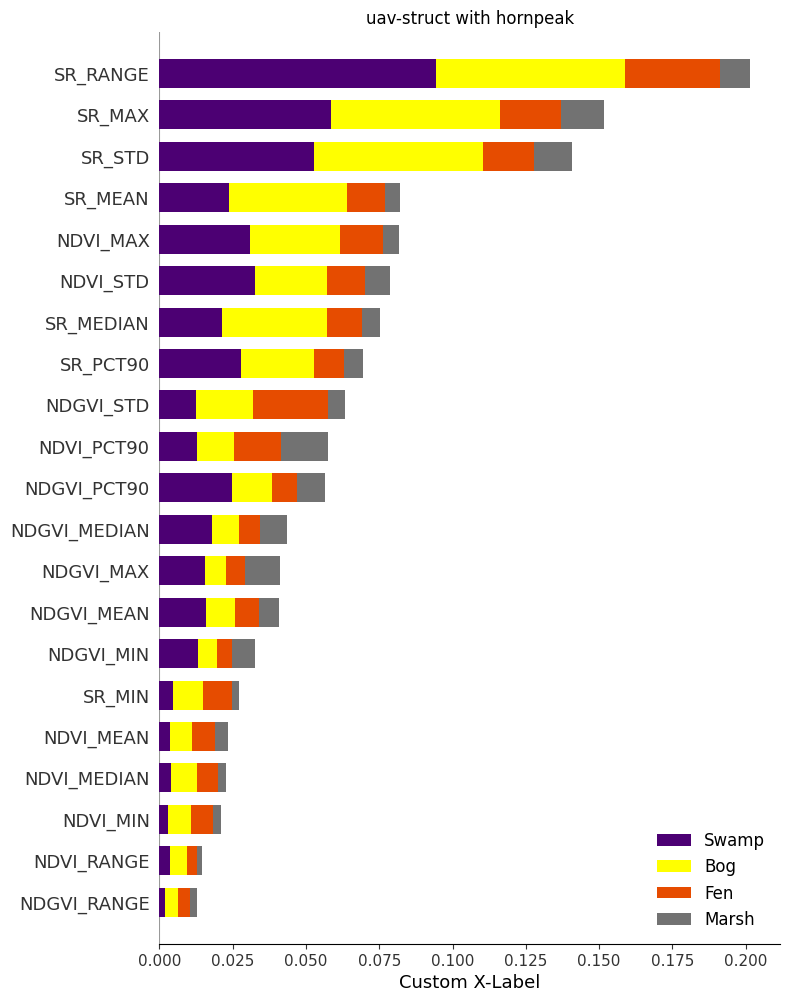

In [13]:
fig = plt.figure()

#shap.summary_plot(shap_values, features=X_test.columns, class_names = classlist, color = cmap, class_inds= 'original', show = False)
shap.summary_plot(
    shap_values,
    features=X_test,                 
    plot_type="bar",                 
    class_names=classlist,
    color = cmap,
    show=False,
    max_display=25
)
plt.title("uav-struct with hornpeak")
plt.xlabel("Custom X-Label")
plt.show()

In [32]:
start = df.columns.get_loc("Al")
end   = df.columns.get_loc("SO4_mg/L") + 1   # +1 to include the end column
all_cols_chem = df.columns[start:end]

# Subset only those columns
chem_df = df[all_cols_chem]

# Calculate % of negative values per column
neg_fraction = (chem_df < 0).mean()

# Filter columns that have < 60% negatives
cols_keep = neg_fraction[neg_fraction < 0.6].index

# Create cleaned dataframe
predictor_cols = cols_keep.tolist()

print(f"Dropped {chem_df.shape[1] - len(predictor_cols)} columns (≥60% negatives)")


Dropped 15 columns (≥60% negatives)


In [33]:
def compute_uscore(obs, cen):
    import numpy as np
    obs = np.asarray(obs, dtype=float)
    cen = np.asarray(cen, dtype=bool)
    n = len(obs)
    u = np.zeros(n)
    for i in range(n):
        for k in range(n):
            if i == k:
                continue
            if (not cen[i]) and (not cen[k]):
                u[i] += np.sign(obs[i] - obs[k])
            elif (not cen[i]) and cen[k]:
                if obs[i] > obs[k]:
                    u[i] += 1
            elif cen[i] and (not cen[k]):
                if obs[i] < obs[k]:
                    u[i] -= 1
            else:  # both censored
                u[i] += np.sign(obs[i] - obs[k])
    return u


In [34]:
import pandas as pd
import numpy as np

chem_uscore = pd.DataFrame(index=chem_df.index)

for col in chem_df.columns:
    obs = chem_df[col].to_numpy()
    
    # Example censor rule: anything < 0 means censored
    cen = obs < 0
    
    if np.sum(cen) == 0:
        chem_uscore[col] = obs  # no censored values → keep raw obs
    else:
        chem_uscore[col] = compute_uscore(obs, cen)

print("=== U-Score summary ===")
print(chem_uscore.describe())


=== U-Score summary ===
              Al         Sb         As         Ba         Be         Bi  \
count  66.000000  66.000000  66.000000  66.000000  66.000000  66.000000   
mean    0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
std    38.391105  37.333425  38.391105  38.391505  29.511406  19.147203   
min   -64.000000 -65.000000 -65.000000 -65.000000 -65.000000 -65.000000   
25%   -32.500000 -39.000000 -32.000000 -32.500000 -15.000000  -4.000000   
50%     0.000000   0.000000   0.000000  -0.500000 -15.000000  -4.000000   
75%    32.500000  32.500000  32.500000  32.500000 -15.000000  -4.000000   
max    65.000000  65.000000  65.000000  65.000000  65.000000  65.000000   

               B         Cd         Ca         Cs  ...         TOC  \
count  66.000000  66.000000  66.000000  66.000000  ...   66.000000   
mean    0.000000   0.000000   0.000000   0.000000  ...   47.805455   
std    26.660833  37.056298  38.391906  29.509321  ...   58.551842   
min   -13.000000 -65

In [35]:
type(chem_uscore)
print(f"chem_uscore has {chem_uscore.shape[1]} columns:\n")
print(chem_uscore.columns.tolist())



chem_uscore has 51 columns:

['Al', 'Sb', 'As', 'Ba', 'Be', 'Bi', 'B', 'Cd', 'Ca', 'Cs', 'Cr', 'Co', 'Cu', 'F', 'Fe', 'Pb', 'Li', 'Mg', 'Mn', 'Mo', 'Ni', 'P', 'K', 'Rb', 'Se', 'Si', 'Ag', 'Na', 'Sr', 'S', 'Te', 'Tl', 'Th', 'Sn', 'Ti', 'W', 'U', 'V', 'Zn', 'Zr', 'DOC', 'TOC', 'P_dissolved', 'P_total', 'NH3_total', 'Alkalinity_total_CaCO3_mg/L', 'Hardness ', 'NO3', 'NO4', 'TDS_mg/L', 'SO4_mg/L']


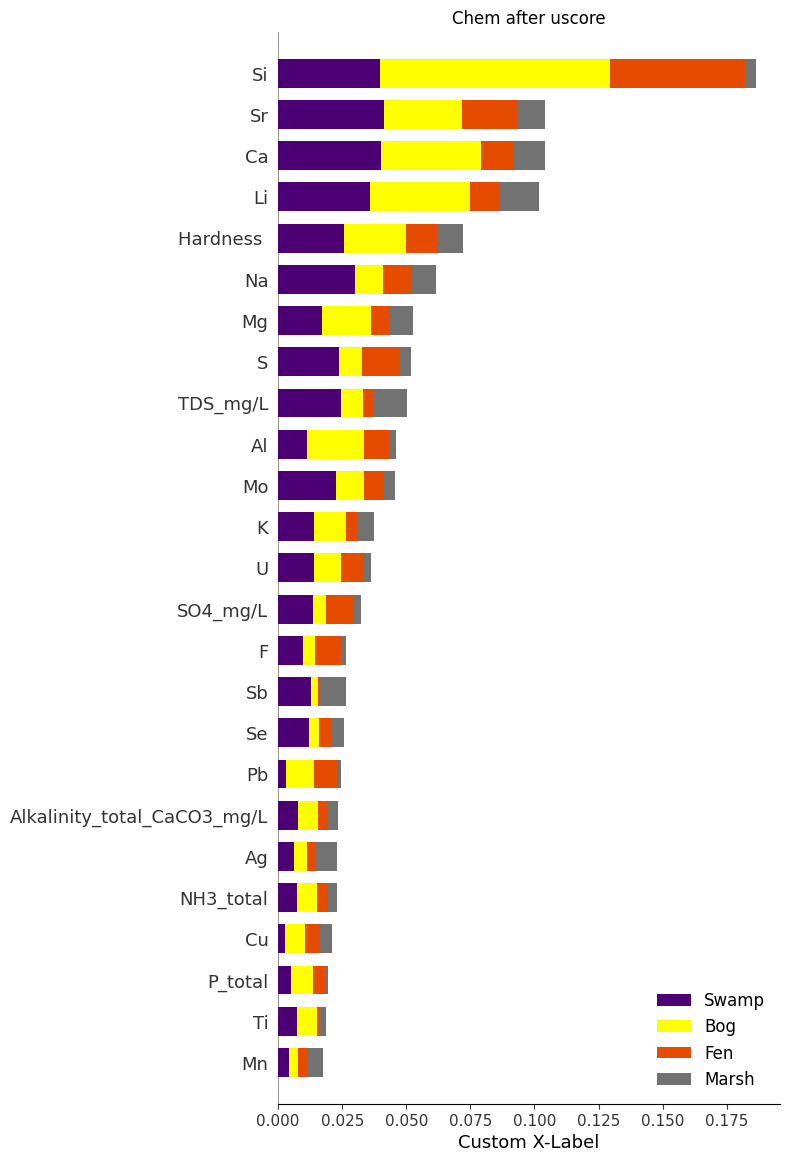

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

#  Use  U-score transformed chemistry data
X = chem_uscore.copy()
y = df["Class"]   # your categorical wetland class labels

# --- train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- fit random forest ---
RF = RandomForestClassifier(n_estimators=300, random_state=42)
RF.fit(X_train, y_train)

# --- SHAP ---
explainer = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_test)

fig = plt.figure()

#shap.summary_plot(shap_values, features=X_test.columns, class_names = classlist, color = cmap, class_inds= 'original', show = False)
shap.summary_plot(
    shap_values,
    features=X_test,                 
    plot_type="bar",                 
    class_names=classlist,
    color = cmap,
    show=False,
    max_display=25
)
plt.title("Chem after uscore")
plt.xlabel("Custom X-Label")
plt.show()


Group Shapley

In [10]:
classlist = ['Marsh', 'Swamp','Fen', 'Bog']   # <- keep in this order; we'll reorder to match RF.classes_
cmap = matplotlib.colors.ListedColormap(['#4C0073','#4C7300','#0070FF','#727272'])

Combine all groups

In [20]:
# sat remotes
start = df.columns.get_loc("NDVI_amp_harmonic")
end   = df.columns.get_loc("TCW_p90") + 1
sat_remotes_cols = df.columns[start:end].tolist()

# topo
start = df.columns.get_loc("SWI_median")
end   = df.columns.get_loc("Geom_mode_10") + 1
topo_cols = df.columns[start:end].tolist()

# UAV veg multispectral indices
start = df.columns.get_loc("NDVI_MIN")
end   = df.columns.get_loc("SR_PCT90") + 1
uav_veg_indices_cols = df.columns[start:end].tolist()

# UAV veg structure
start = df.columns.get_loc("average_veg_height")
end   = df.columns.get_loc("stem_density") + 1
uav_veg_struct_cols = df.columns[start:end].tolist()

# field veg
#start = df.columns.get_loc("tall_tree")
#end   = df.columns.get_loc("equisetum_dom") + 1
#field_veg_cols = df.columns[start:end].tolist()

# chemistry (you said this is in chem_uscore now)
chem_cols = chem_uscore.columns.tolist()

groups_by_type = {
    'sat_remotes': sat_remotes_cols,
    'topo': topo_cols,
    'uav_veg_indices': uav_veg_indices_cols,
    'uav_veg_struct': uav_veg_struct_cols,
    'field_veg': field_veg_cols,
    'chem': chem_cols
}

Bulid X from groups

In [21]:
X_parts = [
    df[sat_remotes_cols],
    df[topo_cols],
    df[uav_veg_indices_cols],
    df[uav_veg_struct_cols],
    #df[field_veg_cols],
    chem_uscore
]
X_all = pd.concat(X_parts, axis=1).select_dtypes(include=[np.number])
X_all = X_all.loc[:, ~X_all.columns.duplicated()]  # safety: drop duplicate names
y = df["Class"]


Run RF and compute SHAP

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, random_state=42, stratify=y
)
RF = RandomForestClassifier(n_estimators=300, random_state=42)
RF.fit(X_train, y_train)

explainer = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_test)   # may be list OR a 3D array

type(shap_values)

numpy.ndarray

In [32]:
from itertools import repeat, chain
revert_dict = lambda d: dict(chain(*[zip(val, repeat(key)) for key, val in d.items()]))

def grouped_shap(shap_vals_2d, features, groups):
    """
    shap_vals_2d: (n_samples, n_features) for ONE class
    features: list of feature names for those columns
    groups:   {'group_name': [feature1, feature2, ...]}
    returns:  DataFrame (n_samples, n_groups) with SHAP summed per group
    """
    groupmap = revert_dict(groups)
    feats = pd.Index(features, name='features')
    # map each feature to a group (drop if not in mapping)
    feat_groups = feats.to_series().map(groupmap)
    keep = feat_groups.notna().values
    if keep.sum() == 0:
        raise ValueError("No overlap between features and groups.")
    df_vals = pd.DataFrame(shap_vals_2d[:, keep], columns=feats[keep])
    df_vals.columns = feat_groups[keep].values
    shap_grouped = df_vals.groupby(axis=1, level=0).sum()
    return shap_grouped

# Normalize SHAP to a list-of-classes of shape (n_samples, n_features)
if isinstance(shap_values, list):
    per_class = shap_values
else:
    arr = np.asarray(shap_values)  # (n_samples, n_features, n_classes)
    per_class = [arr[:, :, k] for k in range(arr.shape[2])]

# Build grouped shap (per class)
features_list = X_test.columns.tolist()
grouped_class_mats = [grouped_shap(sv, features_list, groups_by_type).values for sv in per_class]
group_names = grouped_shap(per_class[0], features_list, groups_by_type).columns.tolist()

C:\Users\leila\AppData\Local\Temp\ipykernel_51512\3921900587.py:20: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  shap_grouped = df_vals.groupby(axis=1, level=0).sum()
C:\Users\leila\AppData\Local\Temp\ipykernel_51512\3921900587.py:20: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  shap_grouped = df_vals.groupby(axis=1, level=0).sum()
C:\Users\leila\AppData\Local\Temp\ipykernel_51512\3921900587.py:20: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  shap_grouped = df_vals.groupby(axis=1, level=0).sum()
C:\Users\leila\AppData\Local\Temp\ipykernel_51512\3921900587.py:20: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  shap_grouped = df_vals.groupby(axis=1, level=0).sum()
C:\Users\leila\AppData\Local\Temp\ipykernel_51512\3921900587.py:20: Futu

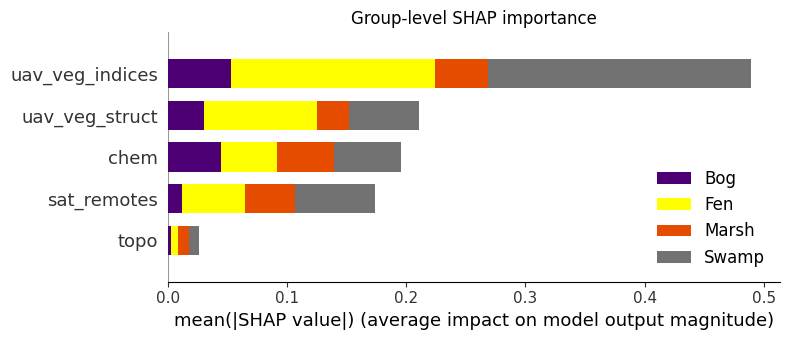

In [33]:
# ===========================================================
# 6) Plot grouped SHAP summary (stacked by class), your style
# ===========================================================
# reorder legend to model’s class order
model_classes = list(RF.classes_)
name_to_idx   = {n:i for i,n in enumerate(classlist)}
legend_names  = [mc if mc in name_to_idx else str(mc) for mc in model_classes]
legend_colors = [cmap.colors[name_to_idx[mc]] if mc in name_to_idx else '#999999'
                 for mc in model_classes]
cmap_ordered  = matplotlib.colors.ListedColormap(legend_colors)

plt.figure(figsize=(9, 3.6))
shap.summary_plot(
    grouped_class_mats,
    features=group_names,
    class_names=legend_names,
    color=cmap,
    class_inds='original',
    plot_type='bar',
    show=False
)
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
plt.title('Group-level SHAP importance')
plt.tight_layout()

# keep save option for later (commented, per your request)
plt.show()


In [34]:
# print a ranked table 
totals = np.zeros(len(group_names))
for g in grouped_class_mats:
    totals += np.mean(np.abs(g), axis=0)
ranked = pd.Series(totals, index=group_names).sort_values(ascending=False)
print("\nGroup importance (sum over classes of mean|SHAP|):\n")
print(ranked.round(4))


Group importance (sum over classes of mean|SHAP|):

uav_veg_indices    0.4890
uav_veg_struct     0.2105
chem               0.1953
sat_remotes        0.1737
topo               0.0263
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from itertools import combinations

# ============
# 0) Colors
# ============
classlist = ['Marsh', 'Swamp','Fen', 'Bog']
cmap = matplotlib.colors.ListedColormap(['#4C0073','#4C7300','#0070FF','#727272'])

# ==================================================
# 1) Define groups EXACTLY the way you’ve been doing
# ==================================================
# sat remotes
start = df.columns.get_loc("NDVI_amp_harmonic")
end   = df.columns.get_loc("TCW_p90") + 1
sat_remotes_cols = df.columns[start:end].tolist()

# topo
start = df.columns.get_loc("SWI_median")
end   = df.columns.get_loc("Geom_mode_10") + 1
topo_cols = df.columns[start:end].tolist()

# UAV veg multispectral indices
start = df.columns.get_loc("NDVI_MIN")
end   = df.columns.get_loc("SR_PCT90") + 1
uav_veg_indices_cols = df.columns[start:end].tolist()

# UAV veg structure
start = df.columns.get_loc("average_veg_height")
end   = df.columns.get_loc("stem_density") + 1
uav_veg_struct_cols = df.columns[start:end].tolist()

# field veg
start = df.columns.get_loc("tall_tree")
end   = df.columns.get_loc("equisetum_dom") + 1
field_veg_cols = df.columns[start:end].tolist()

# chemistry (U-scores you already computed)
chem_cols = chem_uscore.columns.tolist()

groups_by_type = {
    'sat_remotes': sat_remotes_cols,
    'topo': topo_cols,
    'uav_veg_indices': uav_veg_indices_cols,
    'uav_veg_struct': uav_veg_struct_cols,
    #'field_veg': field_veg_cols,
    'chem': chem_cols
}

# helper: build per-group DataFrames (chem comes from chem_uscore)
group_to_df = {
    'sat_remotes': df[sat_remotes_cols],
    'topo': df[topo_cols],
    'uav_veg_indices': df[uav_veg_indices_cols],
    'uav_veg_struct': df[uav_veg_struct_cols],
    #'field_veg': df[field_veg_cols],
    'chem': chem_uscore
}

y = df["Class"]

# ==================================================
# 2) Robust reducer for SHAP to per-feature vector
# ==================================================
def mean_abs_shap_per_feature(shap_values):
    """
    Return (n_features,) mean|SHAP| robust to:
      - list of (n_samples, n_features) per class
      - 3D array (n_samples, n_features, n_classes)
      - 2D array (n_samples, n_features)
    """
    if isinstance(shap_values, list):
        per_class = [np.mean(np.abs(sv), axis=0) for sv in shap_values]
        return np.mean(np.vstack(per_class), axis=0)
    arr = np.asarray(shap_values)
    if arr.ndim == 3:   # (n_samples, n_features, n_classes)
        return np.mean(np.abs(arr), axis=(0, 2))
    if arr.ndim == 2:   # (n_samples, n_features)
        return np.mean(np.abs(arr), axis=0)
    raise ValueError(f"Unexpected shap_values ndim={arr.ndim}")

# ==================================================
# 3) Iterate over ALL combinations of groups
# ==================================================
all_groups = list(groups_by_type.keys())
results = []  # will collect summaries per combo

# Optionally limit combinations during prototyping (e.g., first 10)
MAX_COMBOS = None  # set an int to limit (e.g., 10)

count = 0
for r in range(1, len(all_groups) + 1):  # sizes 1..6
    for combo in combinations(all_groups, r):
        if MAX_COMBOS is not None and count >= MAX_COMBOS:
            break
        count += 1

        combo_name = "+".join(combo)

        # 3a) Build X from the selected groups
        X_parts = [group_to_df[g] for g in combo]
        X_combo = pd.concat(X_parts, axis=1).select_dtypes(include=[np.number])
        X_combo = X_combo.loc[:, ~X_combo.columns.duplicated()]  # drop duplicate names if any

        # 3b) Train/test split
        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X_combo, y, test_size=0.3, random_state=42, stratify=y
            )
        except ValueError:
            # fallback if stratify fails
            X_train, X_test, y_train, y_test = train_test_split(
                X_combo, y, test_size=0.3, random_state=42
            )

        # 3c) Train RF
        RF = RandomForestClassifier(n_estimators=300, random_state=42)
        RF.fit(X_train, y_train)
        test_acc = RF.score(X_test, y_test)

        # 3d) SHAP
        explainer = shap.TreeExplainer(RF)
        shap_values = explainer.shap_values(X_test)

        # 3e) Per-feature mean|SHAP|
        mean_abs = mean_abs_shap_per_feature(shap_values)  # (n_features,)
        assert len(mean_abs) == X_test.shape[1]
        shap_df = pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})

        # 3f) (Optional) Group-level totals for this combo
        group_totals = {}
        for g in combo:
            cols = groups_by_type[g]
            # keep only those present in this X
            use = [c for c in cols if c in X_test.columns]
            if not use:
                continue
            group_totals[g] = shap_df.loc[shap_df["feature"].isin(use), "mean_abs_shap"].sum()

        # 3g) Plot feature-level SHAP bar for this combo (like your big one)
        plt.figure(figsize=(8, 8))
        shap.summary_plot(
            shap_values,
            features=X_test,
            plot_type="bar",
            class_names=classlist,   # legend labels; colors follow SHAP defaults
            show=False,
            max_display=25
        )
        plt.title(f"SHAP feature importance — groups: {combo_name}\n(test acc = {test_acc:.3f}, features={X_test.shape[1]})")
        plt.tight_layout()

        # Optional save (commented, per your request)
        # plt.gcf().savefig(fr"C:\path\to\folder\shap_features_{combo_name}.png", dpi=300, bbox_inches="tight")

        plt.show()

        # 3h) Record summary
        results.append({
            "groups": combo_name,
            "n_features": X_test.shape[1],
            "test_acc": test_acc,
            **{f"SHAP_{k}": v for k, v in group_totals.items()}
        })

# ==========================================
# 4) Summarize all combinations in a table
# ==========================================
summary = pd.DataFrame(results).sort_values(["test_acc", "n_features"], ascending=[False, True])
print("\n=== Combination summary (sorted by test accuracy, then fewer features) ===")
print(summary.fillna(0).round(4))


Full feature set shape: (61, 83)
Model accuracy: 0.895

=== Top 20 Features by mean(|SHAP|) ===
Feature            Mean_abs_SHAP
           SR_MAX 0.029220      
         SR_RANGE 0.029027      
          TCW_p10 0.022001      
   max_veg_height 0.020201      
         NDVI_STD 0.018331      
           SR_STD 0.015908      
    CanopyCover1m 0.013176      
               Si 0.012252      
          TCW_p90 0.011026      
         NDVI_MAX 0.010136      
     stem_density 0.009858      
NDVI_amp_harmonic 0.007870      
         SR_PCT90 0.007361      
        NH3_total 0.006531      
          TCW_p80 0.006522      
               Sr 0.006264      
                U 0.006172      
               Mo 0.006052      
        SR_MEDIAN 0.006014      
          SR_MEAN 0.005929      


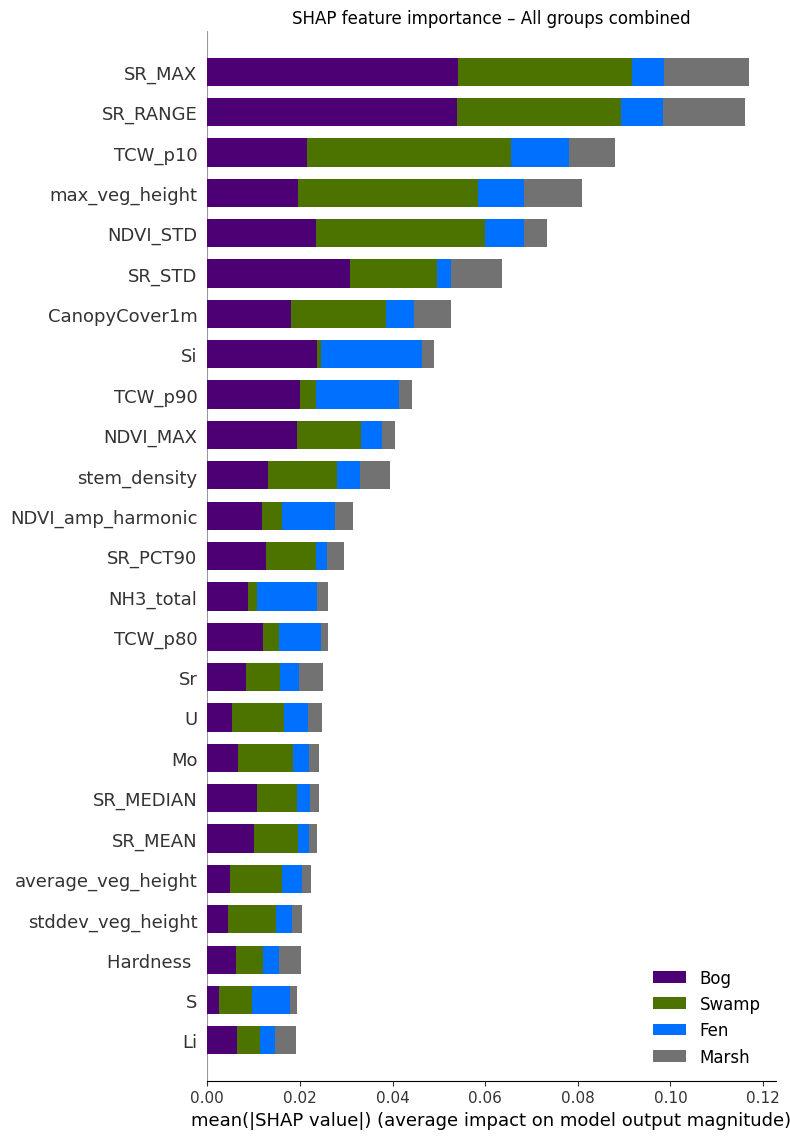

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ========================================
# 1) Define your class colors and legend
# ========================================
classlist = ['Marsh', 'Swamp', 'Fen', 'Bog']
cmap = matplotlib.colors.ListedColormap(['#4C0073', '#4C7300', '#0070FF', '#727272'])

# ========================================
# 2) Define your data groups
# ========================================
# sat remotes
start = df.columns.get_loc("NDVI_amp_harmonic")
end   = df.columns.get_loc("TCW_p90") + 1
sat_remotes_cols = df.columns[start:end].tolist()

# topo
start = df.columns.get_loc("SWI_median")
end   = df.columns.get_loc("Geom_mode_10") + 1
topo_cols = df.columns[start:end].tolist()

# UAV veg multispectral indices
start = df.columns.get_loc("NDVI_MIN")
end   = df.columns.get_loc("SR_PCT90") + 1
uav_veg_indices_cols = df.columns[start:end].tolist()

# UAV veg structure
start = df.columns.get_loc("average_veg_height")
end   = df.columns.get_loc("stem_density") + 1
uav_veg_struct_cols = df.columns[start:end].tolist()

# field vegetation
start = df.columns.get_loc("tall_tree")
end   = df.columns.get_loc("equisetum_dom") + 1
field_veg_cols = df.columns[start:end].tolist()

# chemistry (from your U-score dataframe)
chem_cols = chem_uscore.columns.tolist()

# ========================================
# 3) Combine ALL groups into one dataframe
# ========================================
X_all = pd.concat([
    df[sat_remotes_cols],
    df[topo_cols],
    df[uav_veg_indices_cols],
    df[uav_veg_struct_cols],
    #df[field_veg_cols],
    chem_uscore
], axis=1)

# keep only numeric columns and remove duplicate names
X_all = X_all.select_dtypes(include=[np.number])
X_all = X_all.loc[:, ~X_all.columns.duplicated()]

y = df["Class"]

print(f"Full feature set shape: {X_all.shape}")

# ========================================
# 4) Train-test split and model fit
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, random_state=42, stratify=y
)

RF = RandomForestClassifier(n_estimators=300, random_state=42)
RF.fit(X_train, y_train)

acc = RF.score(X_test, y_test)
print(f"Model accuracy: {acc:.3f}")

# ========================================
# 5) Compute SHAP values
# ========================================
explainer = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_test)

# Create a table
# --- handle multi-class SHAP outputs properly ---
if isinstance(shap_values, list):
    # list of arrays, one per class: (n_samples, n_features)
    shap_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    # single array (binary/multioutput): (n_samples, n_features[, n_classes])
    shap_abs = np.abs(shap_values).mean(axis=0)
    if shap_abs.ndim > 1:
        shap_abs = shap_abs.mean(axis=1)

# --- build and sort a DataFrame of feature importance ---
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_abs_SHAP": shap_abs
}).sort_values("Mean_abs_SHAP", ascending=False)

# --- print and inspect ---
print("\n=== Top 20 Features by mean(|SHAP|) ===")
print(shap_importance.head(20).to_string(index=False, justify="left"))

# --- optional: save to CSV for record keeping ---
# shap_importance.to_csv(r"C:\Users\leila\Dropbox\MayoWetlands\shapley_results\shap_importance_all_groups.csv", index=False)


# ========================================
# 6) SHAP summary plot (all groups together)
# ========================================
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    features=X_test,
    plot_type="bar",
    class_names=classlist,
    color=cmap,
    show=False,
    max_display=25
)
plt.title("SHAP feature importance – All groups combined")
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.tight_layout()

# optional save (commented per your preference)
# plt.savefig(r"C:\Users\leila\Dropbox\MayoWetlands\shapley_results\shapley_all_groups.png", dpi=300, bbox_inches="tight")
plt.show()


In [43]:
groups = {
    "sat_remotes": sat_remotes_cols,
    "topo": topo_cols,
#    "uav_veg_indices": uav_veg_indices_cols,
#    "uav_veg_struct": uav_veg_struct_cols,
#    "field_veg": field_veg_cols,
    "chem": chem_cols
}

group_summary = {}
for g, cols in groups.items():
    group_summary[g] = shap_importance.loc[
        shap_importance["Feature"].isin(cols), "Mean_abs_SHAP"
    ].sum()

group_summary = pd.DataFrame.from_dict(group_summary, orient="index", columns=["Total_SHAP_Importance"])
print("\n=== Total SHAP importance by group ===")
print(group_summary.sort_values("Total_SHAP_Importance", ascending=False))



=== Total SHAP importance by group ===
             Total_SHAP_Importance
chem                      0.099598
sat_remotes               0.054765
topo                      0.009611


Function to things easier

In [ ]:
# ------------- GROUP DEFINITIONS (one-time) -------------
# Sat remotes
sat_start = df.columns.get_loc("NDVI_amp_harmonic")
sat_end   = df.columns.get_loc("TCW_p90") + 1
sat_remotes_cols = df.columns[sat_start:sat_end].tolist()

# Topographic vars
topo_start = df.columns.get_loc("SWI_median")
topo_end   = df.columns.get_loc("Geom_mode_10") + 1
topo_cols  = df.columns[topo_start:topo_end].tolist()

# UAV structure
uavstr_start = df.columns.get_loc("average_veg_height")
uavstr_end   = df.columns.get_loc("stem_density") + 1
uav_structure_cols = df.columns[uavstr_start:uavstr_end].tolist()

# UAV multispectral indices
uavms_start = df.columns.get_loc("NDVI_MIN")
uavms_end   = df.columns.get_loc("SR_PCT90") + 1
uav_ms_cols = df.columns[uavms_start:uavms_end].tolist()

# Chemistry (initial window)
chem_start = df.columns.get_loc("Al")
chem_end   = df.columns.get_loc("SO4_mg/L") + 1
all_cols_chem = df.columns[chem_start:chem_end].tolist()

# ------------- CHEM CLEANING (>60% non-detects dropped) -------------
chem_df = df[all_cols_chem].copy()
neg_fraction = (chem_df < 0).mean()  # "censored" rule (negatives) returns boolean T or F
chem_cols_keep = neg_fraction[neg_fraction < 0.6].index.tolist() # keep only chem vars with < 60% non-detects convert it to a list

def compute_uscore(obs, cen):
    import numpy as np
    obs = np.asarray(obs, dtype=float)
    cen = np.asarray(cen, dtype=bool)
    n = len(obs)
    u = np.zeros(n)
    for i in range(n):
        for k in range(n):
            if i == k:
                continue
            if (not cen[i]) and (not cen[k]):
                u[i] += np.sign(obs[i] - obs[k])
            elif (not cen[i]) and cen[k]:
                if obs[i] > obs[k]:
                    u[i] += 1
            elif cen[i] and (not cen[k]):
                if obs[i] < obs[k]:
                    u[i] -= 1
            else:  # both censored
                u[i] += np.sign(obs[i] - obs[k])
    return u

# empty DataFrame with the same rows 
chem_uscore = pd.DataFrame(index=chem_df.index)

# obs = num cen = True or False
for col in chem_df.columns:
    obs = chem_df[col].to_numpy()
    
    # Example censor rule: anything < 0 means censored
    cen = obs < 0
    
    if np.sum(cen) == 0:
        chem_uscore[col] = obs  # no censored values → keep raw obs
    else:
        chem_uscore[col] = compute_uscore(obs, cen)

print("=== U-Score summary ===")
print(chem_uscore.describe())

# select only chemistry columns that passed 60% test, using their u-scores as the feature
#chem_df[chem_cols_keep].copy() to use raw values
chem_feature_table = chem_uscore[chem_cols_keep].copy()

# ------------- GROUP REGISTRY (for reproducibility) -------------
# dict mapping group names to exact columns they contain
GROUPS = {
    "sat_remotes": sat_remotes_cols,
    "topo": topo_cols,
    "uav_structure": uav_structure_cols,
    "uav_ms": uav_ms_cols,
    "chem": chem_feature_table.columns.tolist(),  # use the cleaned chem col names (just names for now actual values (either raw or ranked) will come later)
}


=== U-Score summary ===
              Al         Sb         As         Ba         Be         Bi  \
count  66.000000  66.000000  66.000000  66.000000  66.000000  66.000000   
mean    0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
std    38.391105  37.333425  38.391105  38.391505  29.511406  19.147203   
min   -64.000000 -65.000000 -65.000000 -65.000000 -65.000000 -65.000000   
25%   -32.500000 -39.000000 -32.000000 -32.500000 -15.000000  -4.000000   
50%     0.000000   0.000000   0.000000  -0.500000 -15.000000  -4.000000   
75%    32.500000  32.500000  32.500000  32.500000 -15.000000  -4.000000   
max    65.000000  65.000000  65.000000  65.000000  65.000000  65.000000   

               B         Cd         Ca         Cs  ...         TOC  \
count  66.000000  66.000000  66.000000  66.000000  ...   66.000000   
mean    0.000000   0.000000   0.000000   0.000000  ...   47.805455   
std    26.660833  37.056298  38.391906  29.509321  ...   58.551842   
min   -13.000000 -65

Helper to assemble X (pred) from any group combo

In [ ]:
def make_predictors(df, groups, group_registry, chem_table=None):
    """
    df: original dataframe (for non-chem groups)
    groups: list of group names, e.g., ["sat_remotes","topo","chem"]
    group_registry: dict name -> list of column names
    chem_table: dataframe holding CHEM feature values IF you want to source chem from a different table
                (e.g., U-scores) while other groups come from df.
    """
    cols = []
    for g in groups:
        if g not in group_registry:
            raise KeyError(f"Unknown group '{g}'. Available: {list(group_registry)}")
        cols.extend(group_registry[g])
    # remove duplicates while preserving order
    seen = set()
    cols_unique = [c for c in cols if not (c in seen or seen.add(c))]

    # Build X by concatenating per-group sources
    frames = []
    non_chem_cols = [c for c in cols_unique if c not in (group_registry.get("chem", []))]
    if non_chem_cols:
        frames.append(df[non_chem_cols])

    if "chem" in groups:
        if chem_table is None:
            frames.append(df[group_registry["chem"]])              # raw (from df)
        else:
            frames.append(chem_table[group_registry["chem"]])      # e.g., U-scores


    X = pd.concat(frames, axis=1)

    # Sanity checks & provenance
    assert X.shape[1] == len(cols_unique), "Column count mismatch after assembly."
    print("\n=== PREDICTOR GROUPS USED ===")
    for g in groups:
        print(f"  - {g}: {len(group_registry[g])} columns")
    print(f"TOTAL predictors used: {X.shape[1]}")
    print("First 10 columns:", list(X.columns[:10]))
    return X, cols_unique


In [ ]:
# Choose the groups for this run
groups_to_use = ["sat_remotes", "topo", "uav_structure", "uav_ms", "chem"]  # edit as needed

# If using U-scores for chem:
# X, predictor_cols = make_predictors(df, groups_to_use, GROUPS, chem_table=chem_uscore)
# If using raw (screened) chem:
X, predictor_cols = make_predictors(df, groups_to_use, GROUPS, chem_table=chem_uscore)

# Target
y = df["Class"]

# Save the exact predictor list (for reproducibility & your Methods/Appendix)
pd.Series(predictor_cols, name="predictor_cols").to_csv("predictors_used_this_run.csv", index=False)
#print('Saved predictor list to "predictors_used_this_run.csv"')



=== PREDICTOR GROUPS USED ===
  - sat_remotes: 7 columns
  - topo: 8 columns
  - uav_structure: 12 columns
  - uav_ms: 21 columns
  - chem: 36 columns
TOTAL predictors used: 84
First 10 columns: ['NDVI_amp_harmonic', 'NDVI_phase_harmonic', 'NDVI_mean_harmonic', 'TCW_p10', 'TCW_p40', 'TCW_p80', 'TCW_p90', 'SWI_median', 'log_MCA_median', 'VDCN_median']
Saved predictor list to "predictors_used_this_run.csv"


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

RF = RandomForestClassifier(n_estimators=300, random_state=42)
RF.fit(X_train, y_train)

explainer = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_test)

def build_shap_table(shap_values, feature_names, class_names=None):
    if isinstance(shap_values, list):
        per_class = [np.abs(sv).mean(axis=0) for sv in shap_values]
        M = np.vstack(per_class).T
        cols = class_names if class_names is not None else [f"class_{i}" for i in range(M.shape[1])]
        df_shap = pd.DataFrame(M, columns=cols, index=feature_names)
        df_shap["MeanAbs_SHAP"] = df_shap.mean(axis=1)
        return df_shap
    arr = np.asarray(shap_values)
    if arr.ndim == 3:
        M = np.abs(arr).mean(axis=0)
        cols = class_names if class_names is not None else [f"class_{i}" for i in range(M.shape[1])]
        df_shap = pd.DataFrame(M, columns=cols, index=feature_names)
        df_shap["MeanAbs_SHAP"] = df_shap.mean(axis=1)
        return df_shap
    elif arr.ndim == 2:
        v = np.abs(arr).mean(axis=0)
        df_shap = pd.DataFrame({"MeanAbs_SHAP": v}, index=feature_names)
        return df_shap
    else:
        raise ValueError(f"Unexpected SHAP array ndim={arr.ndim}, shape={arr.shape}")

class_names = list(RF.classes_)
shap_importance = build_shap_table(shap_values, feature_names=X_test.columns, class_names=class_names)

# Rank + thresholds
shap_importance = shap_importance.sort_values("MeanAbs_SHAP", ascending=False)
shap_importance["RelToMax_pct"] = 100 * shap_importance["MeanAbs_SHAP"] / shap_importance["MeanAbs_SHAP"].max()
shap_importance["Cumulative_pct"] = 100 * shap_importance["MeanAbs_SHAP"].cumsum() / shap_importance["MeanAbs_SHAP"].sum()
shap_importance = shap_importance.reset_index(names="Feature")

print("\nTop 20 features by mean absolute SHAP (test set):")
print(shap_importance.head(20).round(6).to_string(index=False))
shap_importance.to_csv("SHAP_importance_table.csv", index=False)



Top 20 features by mean absolute SHAP (test set):
          Feature      Bog      Fen    Marsh    Swamp  MeanAbs_SHAP  RelToMax_pct  Cumulative_pct
   max_veg_height 0.010483 0.040875 0.010653 0.023145      0.021289    100.000000        5.665290
               Sr 0.008679 0.027097 0.013866 0.021958      0.017900     84.081363       10.428743
               Si 0.002025 0.015729 0.019127 0.033449      0.017583     82.590733       15.107748
           SR_MAX 0.008300 0.024274 0.003293 0.033823      0.017422     81.837922       19.744104
     stem_density 0.011743 0.028855 0.006339 0.022199      0.017284     81.187871       24.343632
         SR_RANGE 0.008140 0.022255 0.003869 0.029800      0.016016     75.231561       28.605719
NDVI_amp_harmonic 0.009152 0.019849 0.009538 0.020235      0.014694     69.019620       32.515880
           SR_STD 0.005449 0.020023 0.003558 0.027971      0.014250     66.937746       36.308098
               Ca 0.006637 0.021794 0.008618 0.019813      0.014216

In [45]:
results = []
for g in GROUPS:
    Xg, cols_g = make_predictors(df, [g], GROUPS, chem_table=chem_uscore)  # or chem_uscore
    Xtr, Xte, ytr, yte = train_test_split(Xg, y, test_size=0.3, random_state=42, stratify=y)
    model = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xtr, ytr)
    acc = model.score(Xte, yte)
    results.append({"Group": g, "n_cols": len(cols_g), "RF_accuracy": acc})

pd.DataFrame(results).sort_values("RF_accuracy", ascending=False)



=== PREDICTOR GROUPS USED ===
  - sat_remotes: 7 columns
TOTAL predictors used: 7
First 10 columns: ['NDVI_amp_harmonic', 'NDVI_phase_harmonic', 'NDVI_mean_harmonic', 'TCW_p10', 'TCW_p40', 'TCW_p80', 'TCW_p90']

=== PREDICTOR GROUPS USED ===
  - topo: 8 columns
TOTAL predictors used: 8
First 10 columns: ['SWI_median', 'log_MCA_median', 'VDCN_median', 'HOFD_median', 'VOFD_median', 'Geom_mode_6', 'Geom_mode_9', 'Geom_mode_10']

=== PREDICTOR GROUPS USED ===
  - uav_structure: 12 columns
TOTAL predictors used: 12
First 10 columns: ['average_veg_height', 'median_veg_height', 'max_veg_height', 'min_veg_height', 'stddev_veg_height', 'P95_veg_height', 'P75_veg_height', 'P25_veg_height', 'IQR_veg_height', 'CanopyCover1m']

=== PREDICTOR GROUPS USED ===
  - uav_ms: 21 columns
TOTAL predictors used: 21
First 10 columns: ['NDVI_MIN', 'NDVI_MAX', 'NDVI_RANGE', 'NDVI_MEAN', 'NDVI_STD', 'NDVI_MEDIAN', 'NDVI_PCT90', 'NDGVI_MIN', 'NDGVI_MAX', 'NDGVI_RANGE']

=== PREDICTOR GROUPS USED ===
  - chem: 36

,Group,n_cols,RF_accuracy
0,sat_remotes,7,0.85
1,topo,8,0.85
2,uav_structure,12,0.80
3,uav_ms,21,0.80
4,chem,36,0.80
